#### Title: An Analysis of a UK-Based Online Store's Customer Transaction Data 
#### Dataset: Online Retail.xlsx
#### Source: [Coursera] (https://www.coursera.org/projects/perform-exploratory-data-analysis-on-retail-data-with-python)
#### Objectives:
1. Assess sales trends over time (daily, monthly, yearly, day of week, seasons)
2. Assess sales trends by country (top-selling vS low-selling)
3. Assess sales trends by product (top-selling vS low-selling)
4. Determine the number Of orders generated by month
5. Compare monthly revenue and monthly Orders
6. Determine monthly average order value
7. Determine most valuable customer(s)
8. Determine product popularity (by country)
9. Provide an high-level view of sales performance

#### Load Dataset + EDA

In [59]:
# Import Libraries
import pandas as pd # for reading dataset 
import numpy as np # for array handling
import matplotlib.pyplot as plt # for visualisations

In [60]:
# Read dataset
df = pd.read_excel('Online Retail.xlsx')

# Display top rows
df.head() 

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [61]:
# Display bottom rows
df.tail() 

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [62]:
# Display dataset summary
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


***Interpretation:*** The dataset has 541909 rows and 8 columns. The columns are their datatypes are:
- InvoiceNo: object
- StockCode: object
- Description: object
- Quantity: integer
- InvoiceDate: datetime
- UnitPrice: float
- CustomerID: float
- Country: object

In [63]:
# Display dataset descriptive info
df.describe(include='all') 

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


***Interpretation:*** The descriptive statistics provided for the dataset column are: count (no. of rows), unique (distinct values of object column), top (first value of object column), freq (occurrence of values of object column), mean (average of numeric & datetime column), min (smallest value of numeric & datetime columns), 25% (1st quartile of numeric & datetime columns), 50% (2nd quartile or median of numeric & datetime columns), 75% (3rd quartile of numeric & datetime columns), max (largest value of numeric & datetime columns) and std (standard deviation of numeric columns).

In [64]:
# Display no. of duplicate rows
df.duplicated().sum() 

np.int64(5268)

***Interpretation:*** 5268 duplicate rows were identified in the dataset. These rows must be removed to avoid inflated sales performance results.

In [65]:
# Display duplicate rows
df[df.duplicated()] 

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446.0,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom
541699,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom


***Note:*** Output of the duplicate rows.

In [66]:
# Count missing values
df.isnull().sum() 

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

***Interpretation:*** Columns 'Description' and 'CustomerID' has 1454 and 135080 missing values, respectively.

In [67]:
# Count transactions with negative quantities
negative_quantity_count = (df["Quantity"] < 0).sum()

print(
    "Transactions with negative quantities:",
    negative_quantity_count
)

Transactions with negative quantities: 10624


***Interpretation:*** 10624 rows of negative quantities were identified in the dataset. These represent returns or cancelled orders and should be excluded from the analysis as they do not reflect 'true sales'. Therefore, these may offset the sales performance results.

In [68]:
# Display the first 10 transactions with negative quantities
negative_transactions = df[
    df["Quantity"] < 0
]

negative_transactions.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


***Interpretation:*** Sample of rows with negative quantities.

In [69]:
# Clean Data

# Create dataset copy
df_clean = df.copy()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Remove rows without a product description
df_clean = df_clean[
    df_clean["Description"].notna()
]

# Keep positive quantities
df_clean = df_clean[
    df_clean["Quantity"] >= 1
]

# Keep unit prices of at least £1
df_clean = df_clean[
    df_clean["UnitPrice"] >= 1
]

***Interpretation:*** The first stage of the data cleaning involved creating a variable to store a cleaned copy of the dataset. Next, was dropping duplicate rows, rows without description, rows with negative quantity and negative unit price values.

In [70]:
# Clean Data

# List of descriptions that are not normal products
non_product_descriptions = [
    "?",
    "Adjust bad debt",
    "amazon",
    "AMAZON FEE",
    "Bank Charges",
    "check",
    "CARRIAGE",
    "CRUK Commission",
    "damages",
    "DOTCOM POSTAGE",
    "Discount",
    "Manual",
    "Next Day Carriage",
    "POSTAGE",
    "SAMPLES",
    "samples"
]

# Remove these transactions
df_clean = df_clean[
    ~df_clean["Description"].isin(
        non_product_descriptions
    )
]

***Interpretation:*** Rows with non-product-related descriptions were also dropped.

In [71]:
# Clean Data

# Convert InvoiceNo to string
df_clean["InvoiceNo"] = (
    df_clean["InvoiceNo"]
    .astype(str)
)

# Remove cancelled invoices beginning with C
df_clean = df_clean[
    ~df_clean["InvoiceNo"].str.startswith("C")
]

# Remove adjustment records beginning with A
df_clean = df_clean[
    ~df_clean["InvoiceNo"].str.startswith("A")
]

***Interpretation:*** Furthermore, the datatype of InvoiceNo was changed to string to allow checking of the first character; rows with invoice numbers starting with 'C' denoting cancellations; and rows with invoice numbers starting with 'A' denoting adjustments were also dropped.    

In [72]:
# Display the size of the cleaned dataset
print("Rows remaining:", df_clean.shape[0])

print("Columns remaining:", df_clean.shape[1])

Rows remaining: 413015
Columns remaining: 8


***Interpretation:*** After cleaning the data, 413015 rows and 8 columns are remaining.

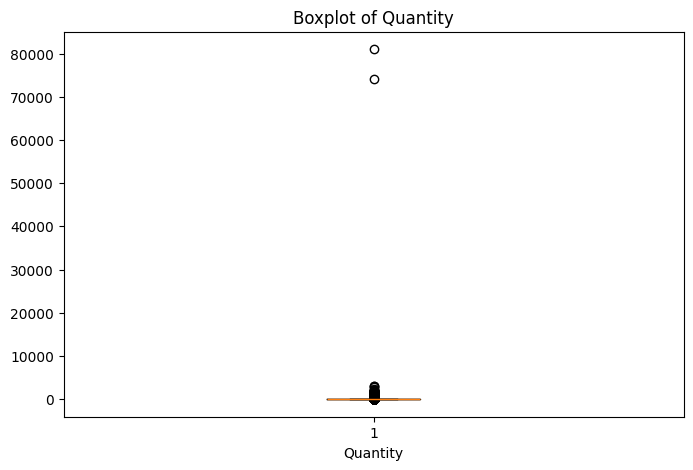

In [73]:
# Create a boxplot of Quantity
plt.figure(figsize=(8, 5))

plt.boxplot(
    df_clean["Quantity"].dropna()
)

plt.title("Boxplot of Quantity")
plt.xlabel("Quantity")

plt.show()

***Interpretation:*** A boxplot of 'Quantity' column was generated to view the data's distribution in a graphical format. Based on this plot, 2 outliers exist in the data, which could represent true bulk yet unusually large orders or erroneous large orders. Further investigation of these quantities will determine whether they are genuine entries; however, these will be dropped from this analysis to prevent unwanted influence.

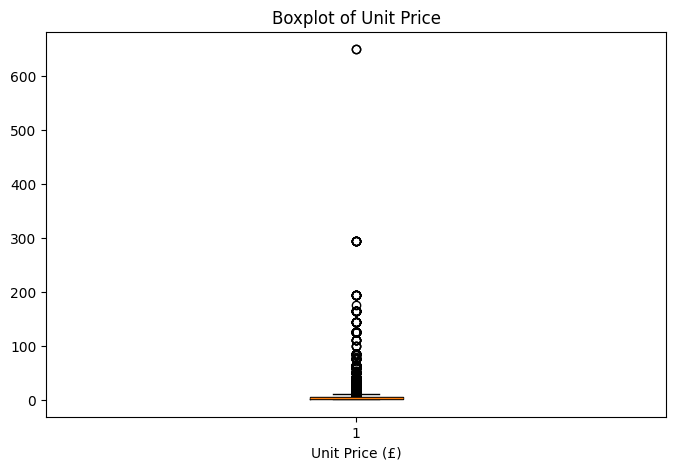

In [74]:
# Create a boxplot of UnitPrice
plt.figure(figsize=(8, 5))

plt.boxplot(
    df_clean["UnitPrice"].dropna()
)

plt.title("Boxplot of Unit Price")
plt.xlabel("Unit Price (£)")

plt.show()

***Interpretation:*** A boxplot of 'Unit Price' column was also created to view the distribution of the data. Based on the plot, there are 2 outliers which could represent data entry errors or true high prices. Further investigation of these unit prices will determine whether they are genuine entries; however, these will be dropped from this analysis to prevent unwanted influence.

In [75]:
# Calculate Q1 and Q3 for Quantity
Q1_quantity = df_clean["Quantity"].quantile(0.25)
Q3_quantity = df_clean["Quantity"].quantile(0.75)

# Calculate the IQR
IQR_quantity = (
    Q3_quantity - Q1_quantity
)

print("Q1:", Q1_quantity)
print("Q3:", Q3_quantity)
print("IQR:", IQR_quantity)

Q1: 1.0
Q3: 8.0
IQR: 7.0


***Interpretation:*** The Q1 value for 'Quantity' suggests that 25% of the data falls below 1 while its Q3 value suggests that 75% of the data falls below 8. Its IQR (interquartile range) of 7 also suggests a small spread of the middle 50% of the data, meaning that most quantities are relatively close in value.

In [76]:
# Calculate Q1 and Q3 for UnitPrice
Q1_price = df_clean["UnitPrice"].quantile(0.25)
Q3_price = df_clean["UnitPrice"].quantile(0.75)

# Calculate the IQR
IQR_price = (
    Q3_price - Q1_price
)

print("Q1:", Q1_price)
print("Q3:", Q3_price)
print("IQR:", round(IQR_price, 2))

Q1: 1.65
Q3: 4.95
IQR: 3.3


***Interpretation:*** The Q1 value for 'Unit Price' suggests that 25% of the data fall below 1.65 while its Q3 value suggests that 75% of the data falls below 4.95. Its IQR (interquartile range) of 3.3 also suggests a very small spread of the middle 50% of the data, meaning that most unit prices are very close in value.

In [77]:
# Calculate quantity boundaries
quantity_lower = (
    Q1_quantity -
    1.5 * IQR_quantity
)

quantity_upper = (
    Q3_quantity +
    1.5 * IQR_quantity
)

# Calculate price boundaries
price_lower = (
    Q1_price -
    1.5 * IQR_price
)

price_upper = (
    Q3_price +
    1.5 * IQR_price
)

print("Quantity lower limit:", quantity_lower)
print("Quantity upper limit:", quantity_upper)

print("Price lower limit:", round(price_lower, 2))
print("Price upper limit:", round(price_upper, 2))

Quantity lower limit: -9.5
Quantity upper limit: 18.5
Price lower limit: -3.3
Price upper limit: 9.9


***Interpretation:*** The boundaries of the data to be retained are as follows:
- -9.5 ≤ 'Quantity' ≤ 18.5
- -3.3 ≤ 'Unit Price' ≤ 9.9

In [78]:
# Remove observations outside the calculated boundaries
df_clean = df_clean[
    (df_clean["Quantity"] >= quantity_lower) &
    (df_clean["Quantity"] <= quantity_upper) &
    (df_clean["UnitPrice"] >= price_lower) &
    (df_clean["UnitPrice"] <= price_upper)
]

***Interpretation:*** Rows outside the boundaries for 'Quantity' and 'Unit Price' are dropped from further analysis.

#### Deeper Analysis

In [79]:
# Count unique countries
number_of_countries = (
    df_clean["Country"]
    .nunique()
)

print(
    "Number of unique countries:",
    number_of_countries
)

Number of unique countries: 38


***Interpretation:*** 38 different countries were identified in the dataset.

In [80]:
# Display unique products
unique_products = (
    df_clean[
        ["StockCode", "Description"]
    ]
    .drop_duplicates()
    .sort_values("Description")
)

unique_products

,StockCode,Description
1057,72800B,4 PURPLE FLOCK DINNER CANDLES
309257,23437,50'S CHRISTMAS GIFT BAG LARGE
276939,23345,DOLLY GIRL BEAKER
334343,23391,I LOVE LONDON MINI BACKPACK
379954,23391,I LOVE LONDON MINI RUCKSACK
...,...,...
171809,23145,ZINC T-LIGHT HOLDER STAR LARGE
170758,23144,ZINC T-LIGHT HOLDER STARS SMALL
1827,84832,ZINC WILLIE WINKIE CANDLE STICK
527189,23143,ZINC WIRE KITCHEN ORGANISER


***Note:*** Output of the different products purchased by customers

In [81]:
# Count unique products
number_of_products = (
    unique_products.shape[0]
)

print(
    "Number of unique products:",
    number_of_products
)

Number of unique products: 3535


***Interpretation:*** 3535 different products were identified in the dataset.

In [82]:
# Calculate sales revenue for every transaction
df_clean["Sales"] = (
    df_clean["Quantity"] *
    df_clean["UnitPrice"]
)

# Display the first few transactions
df_clean[
    [
        "InvoiceNo",
        "Description",
        "Quantity",
        "UnitPrice",
        "Sales"
    ]
].head()

,InvoiceNo,Description,Quantity,UnitPrice,Sales
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30
1,536365,WHITE METAL LANTERN,6,3.39,20.34
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2.75,22.00
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,20.34
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,20.34


***Interpretation:*** Sales calculated as 'Quantity' x 'Unit Price' forms the basis for measuring the retail store's sales performance. 

In [83]:
# Convert InvoiceDate to datetime format
# df_clean["InvoiceDate"] = pd.to_datetime(
#    df_clean["InvoiceDate"]
# )

# Create a separate date column
df_clean["Date"] = (
    df_clean["InvoiceDate"]
    .dt.date
)

# Display the first dates
df_clean["Date"].head()

0    2010-12-01
1    2010-12-01
2    2010-12-01
3    2010-12-01
4    2010-12-01
Name: Date, dtype: object

***Interpretation:*** A 'Date' column is derived from the 'InvoiceDate' column to facilitate date-related analysis, namely the retail store's sales trends over time. 

In [84]:
# Find the earliest transaction date
earliest_date = df_clean["Date"].min()

# Find the latest transaction date
latest_date = df_clean["Date"].max()

print("Earliest transaction:", earliest_date)
print("Latest transaction:", latest_date)

Earliest transaction: 2010-12-01
Latest transaction: 2011-12-09


***Interpretation:*** The date range of the dataset is examined to help inform the retail store's sales growth/decline patterns. With the earliest date being Dec 2010 and the latest Dec 2011, the data is likely to reflect sales performance of 2011 primarily.

In [85]:
# Calculate total sales for each day
daily_sales = (
    df_clean
    .groupby("Date")["Sales"]
    .sum()
    .reset_index()
)

# Rename the sales column
daily_sales.columns = [
    "Date",
    "Total_Sales"
]

# Display the first few days
daily_sales.head()

,Date,Total_Sales
0,2010-12-01,23716.09
1,2010-12-02,19525.48
2,2010-12-03,18821.40
3,2010-12-05,18679.71
4,2010-12-06,28908.30


***Interpretation:*** An examination of sales per day can give the retail store's owners an idea of typical vs non-typical days for customer purchases.

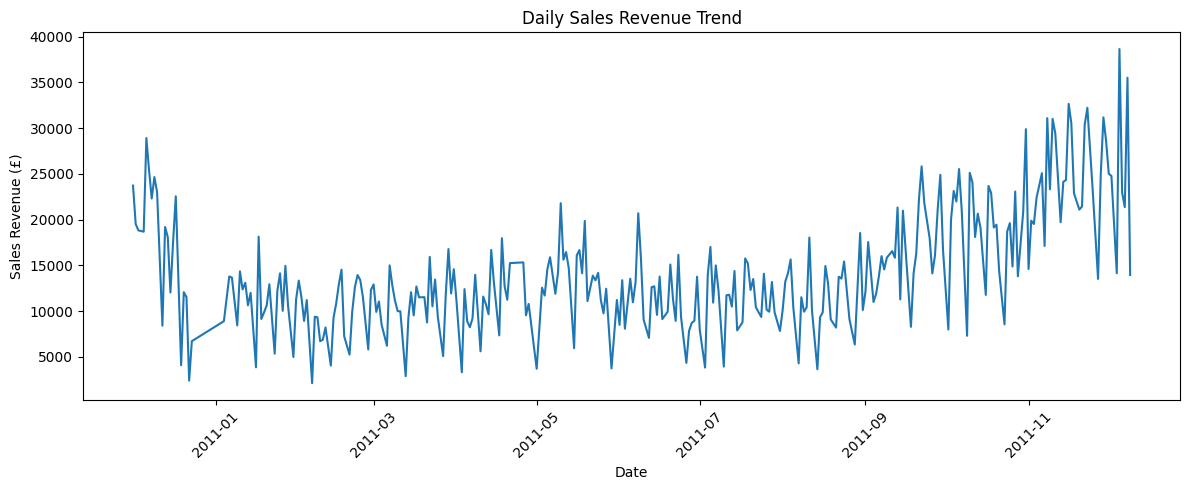

In [86]:
# Plot daily sales revenue
plt.figure(figsize=(12, 5))

plt.plot(
    daily_sales["Date"],
    daily_sales["Total_Sales"]
)

plt.title(
    "Daily Sales Revenue Trend"
)

plt.xlabel("Date")
plt.ylabel("Sales Revenue (£)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

***Interpretation:*** The daily sales revenue trend for 2010-2011 show primarily sharp rises and falls. There is a staggered fall in sales in late 2010 and a gradual yet staggered increase in sales in late 2011 (roughly Nov to Dec). For the retail store, these rises and falls could be due to
rapidly changing customer demands, attractive and/or unattractive sales promotions, inventory shortages or operational disruptions
(e.g. website/payment system downtime, delivery delays).

In [87]:
# Create a Year-Month variable
df_clean["YearMonth"] = (
    df_clean["InvoiceDate"]
    .dt.to_period("M")
    .astype(str)
)

# Calculate monthly sales
monthly_sales = (
    df_clean
    .groupby("YearMonth")["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.columns = [
    "YearMonth",
    "Total_Sales"
]

monthly_sales.head()

,YearMonth,Total_Sales
0,2010-12,339693.44
1,2011-01,266619.60
2,2011-02,231309.41
3,2011-03,295317.36
4,2011-04,234846.65


***Interpretation:*** The retail store's owners can use monthly sales for more strategic planning (eg. increasing inventory
given repeated demand) and to be informed of seasonality (eg. high sales around national holidays like Christmas).


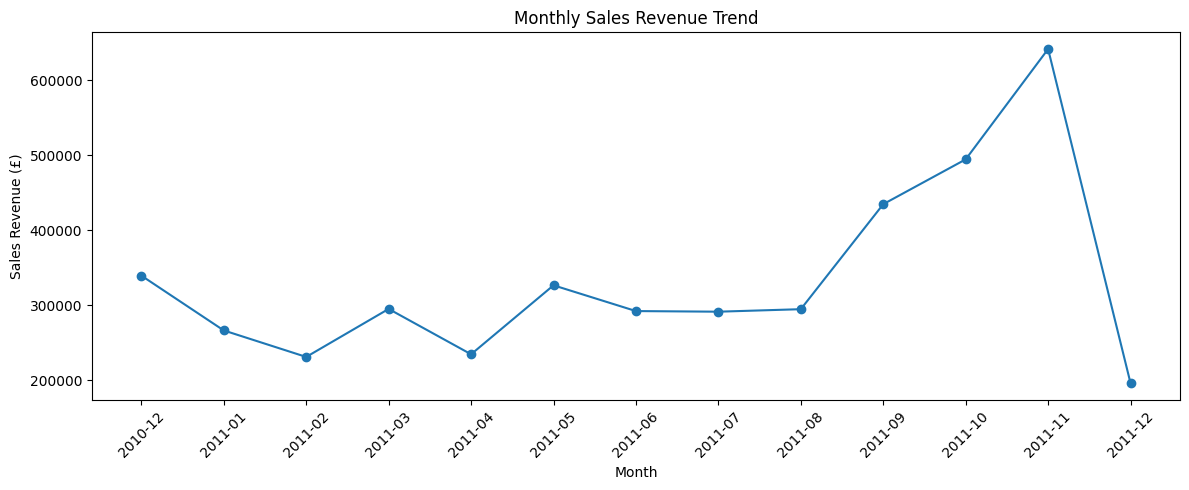

In [88]:
# Plot monthly sales revenue
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["YearMonth"],
    monthly_sales["Total_Sales"],
    marker="o"
)

plt.title(
    "Monthly Sales Revenue Trend"
)

plt.xlabel("Month")
plt.ylabel("Sales Revenue (£)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

***Interpretation:***  The monthly sales revenue trend shows lower sales in Dec 2010 to Aug 2011. This pattern could be
due to weak customer demand and/or promotion by the retail store. Its sales increased after Aug 2011 to Nov 2011 then declined dramatically
again in Dec 2011. This is an expected demand pattern nearing holiday seasons except for the decline in Dec 2011 which needs further investigation.

In [89]:
# Sort months from highest to lowest sales
top_months = (
    monthly_sales
    .sort_values(
        "Total_Sales",
        ascending=False
    )
)

# Display the 10 strongest months
top_months.head(10)

,YearMonth,Total_Sales
11,2011-11,641792.34
10,2011-10,494707.43
9,2011-09,434966.17
0,2010-12,339693.44
5,2011-05,326801.68
3,2011-03,295317.36
8,2011-08,294970.38
6,2011-06,292457.54
7,2011-07,291629.69
1,2011-01,266619.60


***Interpretation:***  The best sales months were primarily in the 3rd and 4th quarters of both years. This could be due to greater global customer demand given additional promotions, new product launches or changes to customer buying patterns.

In [90]:
# Sort months from lowest to highest sales
bottom_months = (
    monthly_sales
    .sort_values(
        "Total_Sales",
        ascending=True
    )
)

# Display the 10 weakest months
bottom_months.head(10)

,YearMonth,Total_Sales
12,2011-12,196308.69
2,2011-02,231309.41
4,2011-04,234846.65
1,2011-01,266619.60
7,2011-07,291629.69
6,2011-06,292457.54
8,2011-08,294970.38
3,2011-03,295317.36
5,2011-05,326801.68
0,2010-12,339693.44


***Interpretation:*** The weakest sales months were mainly in the 2nd and 3rd quarters of both years. This finding could be further compared against inventory levels, product options, promotion efforts, operational problems (if any) and customer buying patterns at that time for greater context.

In [91]:
# Create a Year variable
df_clean["Year"] = (
    df_clean["InvoiceDate"]
    .dt.year
)

# Calculate annual sales
yearly_sales = (
    df_clean
    .groupby("Year")["Sales"]
    .sum()
    .reset_index()
)

yearly_sales.columns = [
    "Year",
    "Total_Sales"
]

yearly_sales

,Year,Total_Sales
0,2010,339693.44
1,2011,4001726.94


***Interpretation:***  This yearly sales data provides the retail store's owners with a high level view of revenue. However, as 2010 only has one month
represented in the dataset, this imbalance gives favour to higher sales in 2011. Consequently, the results are unsuitable for determining true
demand for either year.

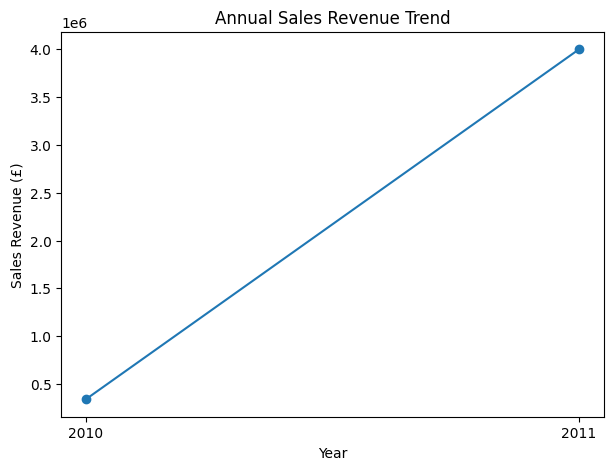

In [92]:
# Plot annual sales
plt.figure(figsize=(7, 5))

plt.plot(
    yearly_sales["Year"],
    yearly_sales["Total_Sales"],
    marker="o"
)

plt.title(
    "Annual Sales Revenue Trend"
)

plt.xlabel("Year")
plt.ylabel("Sales Revenue (£)")

plt.xticks(
    yearly_sales["Year"]
)

plt.show()

***Interpretation:***  The data shows an increase in yearly sales from 2010 to 2011 for the retail store; almost 12 times that of 2010. Yet, this is fostered by a dataset imbalance.

In [93]:
# Create day-of-week variable
df_clean["DayOfWeek"] = (
    df_clean["InvoiceDate"]
    .dt.day_name()
)

# Calculate sales by day
day_sales = (
    df_clean
    .groupby("DayOfWeek")["Sales"]
    .sum()
    .reset_index()
)

day_sales.columns = [
    "DayOfWeek",
    "Total_Sales"
]

day_sales

,DayOfWeek,Total_Sales
0,Friday,699910.00
1,Monday,733881.45
2,Sunday,447203.03
3,Thursday,880819.47
4,Tuesday,817319.34
5,Wednesday,762287.09


***Interpretation:*** An analysis of the sales per day of the week helps the retail store's owners to identify the weekday(s) that see the most versus least revenue. The store's owners may then dynamically adjust staffing and efficiency to fulfill orders, timing of promotions and advertising and inventory reorder schedules.

In [94]:
# Define the correct weekday order
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Convert DayOfWeek to an ordered categorical variable
day_sales["DayOfWeek"] = pd.Categorical(
    day_sales["DayOfWeek"],
    categories=weekday_order,
    ordered=True
)

# Sort by weekday
day_sales = (
    day_sales
    .sort_values("DayOfWeek")
)

day_sales

,DayOfWeek,Total_Sales
1,Monday,733881.45
4,Tuesday,817319.34
5,Wednesday,762287.09
3,Thursday,880819.47
0,Friday,699910.00
2,Sunday,447203.03


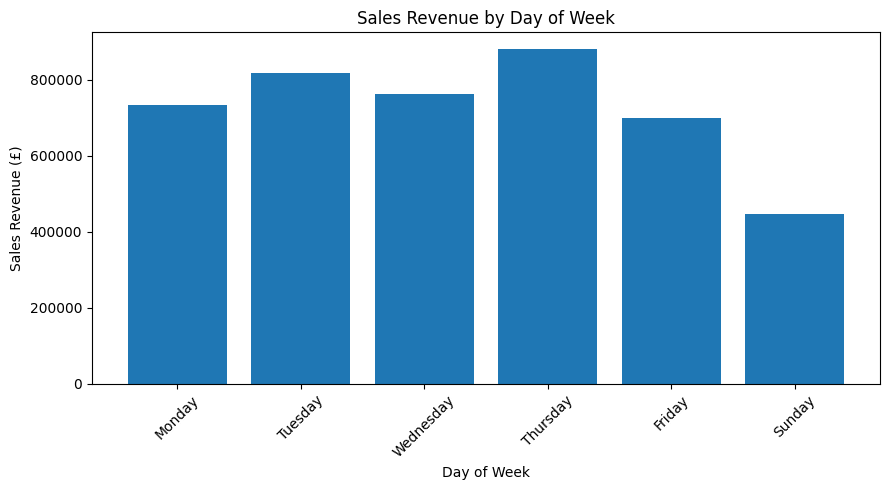

In [95]:
# Plot sales by weekday
plt.figure(figsize=(9, 5))

plt.bar(
    day_sales["DayOfWeek"],
    day_sales["Total_Sales"]
)

plt.title(
    "Sales Revenue by Day of Week"
)

plt.xlabel("Day of Week")
plt.ylabel("Sales Revenue (£)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

***Interpretation:***  Tuesdays and Thursdays reflect similar and the highest revenues. Mondays, Wednesdays and Fridays also had similar but
lower revenue with Sunday having the lowest revenue. The retail store's owners may apply any or some of the strategies as previously suggested
to capitalize on the "high revenue" days or boost sales on revenue" day.

In [96]:
# Create a month number
df_clean["Month"] = (
    df_clean["InvoiceDate"]
    .dt.month
)

# Calculate total sales by calendar month
monthly_seasonality = (
    df_clean
    .groupby("Month")["Sales"]
    .sum()
    .reset_index()
)

monthly_seasonality.columns = [
    "Month",
    "Total_Sales"
]

monthly_seasonality

,Month,Total_Sales
0,1,266619.60
1,2,231309.41
2,3,295317.36
3,4,234846.65
4,5,326801.68
5,6,292457.54
6,7,291629.69
7,8,294970.38
8,9,434966.17
9,10,494707.43


***Interpretation:*** Monthly seasonality helps the retail store's owners identify which month(s) overall had the best sales, specifically seasonality
patterns. Therefore, the owners could implement strategies including acquiring adequate stock, increase advertising/marketing
efforts and optimizing order fulfillment operations ahead of these peak seasons.

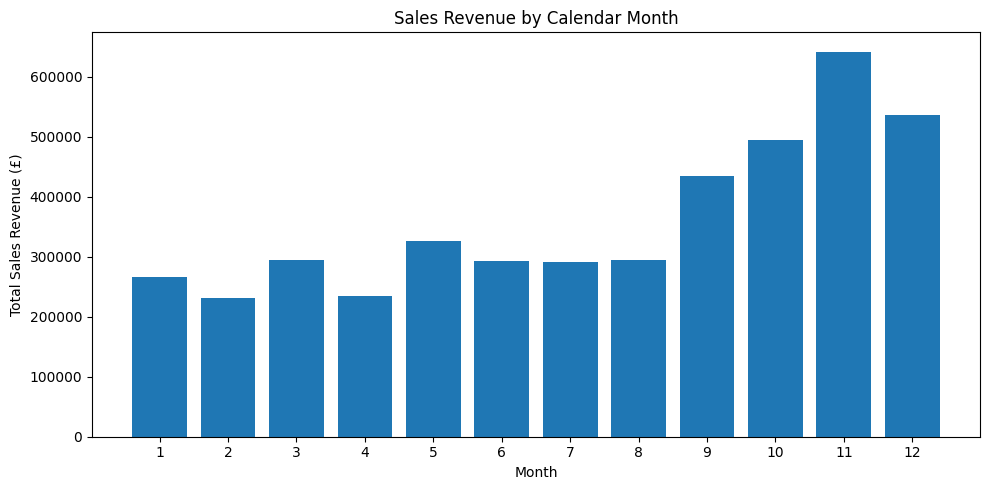

In [97]:
# Plot sales by calendar month
plt.figure(figsize=(10, 5))

plt.bar(
    monthly_seasonality["Month"],
    monthly_seasonality["Total_Sales"]
)

plt.title(
    "Sales Revenue by Calendar Month"
)

plt.xlabel("Month")
plt.ylabel("Total Sales Revenue (£)")

plt.xticks(
    range(1, 13)
)

plt.tight_layout()

plt.show()

***Interpretation:*** The bar chart shows sales growth from Sept to Dec, with Nov having the highest sales, a potential case of seasonality. These levels could be attributed to increased customer buying for holidays like Thanksgiving and Christmas celebrated during that time.

In [98]:
# Calculate total sales by country
country_sales = (
    df_clean
    .groupby("Country")["Sales"]
    .sum()
    .reset_index()
)

country_sales.columns = [
    "Country",
    "Total_Sales"
]

# Sort from highest to lowest
country_sales = (
    country_sales
    .sort_values(
        "Total_Sales",
        ascending=False
    )
)

# Display the top 10 countries
country_sales.head(10)

,Country,Total_Sales
36,United Kingdom,3824428.75
14,Germany,112048.66
10,EIRE,97781.80
13,France,95621.28
31,Spain,25233.63
33,Switzerland,24192.41
3,Belgium,24170.98
27,Portugal,16111.71
25,Norway,14674.99
24,Netherlands,11446.01


***Interpretation:*** Most of the online retail store's sales result from its base country, the United Kingdom. This may be in its owners' best favour as their marketing and shipping efforts can be minimal. However, this also presents a grand opportunity for greater international, country-specific marketing and improving shipping operations, therefore catering to a wider customer base.

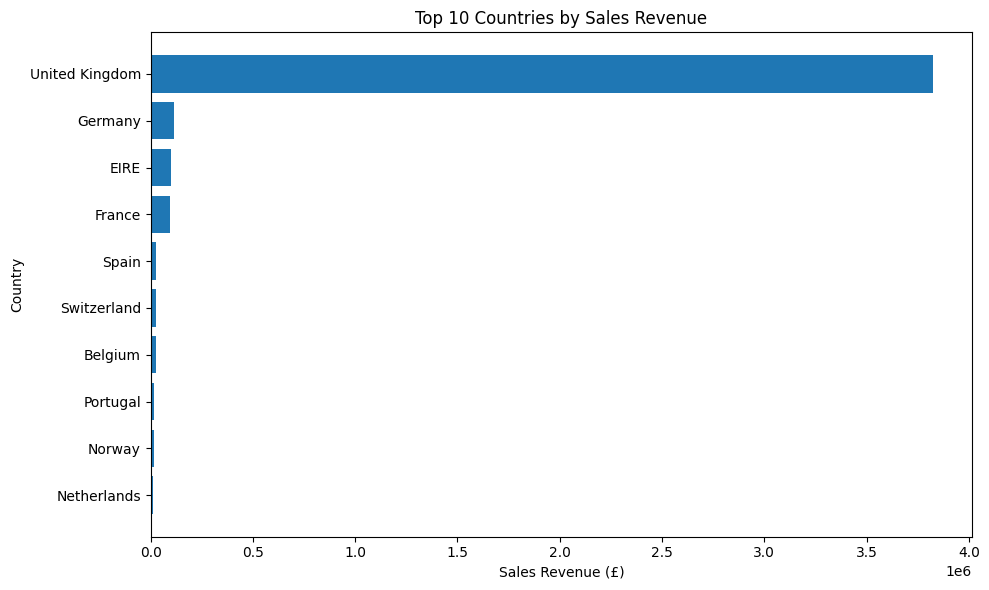

In [99]:
# Select the top 10 countries
top_countries = country_sales.head(10)

# Plot the results
plt.figure(figsize=(10, 6))

plt.barh(
    top_countries["Country"][::-1],
    top_countries["Total_Sales"][::-1]
)

plt.title(
    "Top 10 Countries by Sales Revenue"
)

plt.xlabel("Sales Revenue (£)")
plt.ylabel("Country")

plt.tight_layout()

plt.show()

***Interpretation:*** The United Kingdom's revenue is the millions while its runner ups' are in the hundreds of thousands. These countries (Netherlands,
EIRE, Germany, France) are however good targets for further marketing efforts by the retail store to drive their revenue close to or matching that of
the United Kingdom.

In [100]:
# Calculate total revenue for each product
product_sales = (
    df_clean
    .groupby(
        ["StockCode", "Description"]
    )["Sales"]
    .sum()
    .reset_index()
)

product_sales.columns = [
    "StockCode",
    "Description",
    "Total_Sales"
]

# Sort from highest to lowest
product_sales = (
    product_sales
    .sort_values(
        "Total_Sales",
        ascending=False
    )
)

# Display the top 10 products
product_sales.head(10)

,StockCode,Description,Total_Sales
2302,47566,PARTY BUNTING,33175.65
3195,85123A,WHITE HANGING HEART T-LIGHT HOLDER,32139.11
3183,85099B,JUMBO BAG RED RETROSPOT,24142.42
1562,22960,JAM MAKING SET WITH JARS,23919.30
1906,23298,SPOTTY BUNTING,22060.05
1138,22457,NATURAL SLATE HEART CHALKBOARD,20110.41
2473,84879,ASSORTED COLOUR BIRD ORNAMENT,18952.95
806,22086,PAPER CHAIN KIT 50'S CHRISTMAS,18687.07
1353,22726,ALARM CLOCK BAKELIKE GREEN,18599.16
1354,22727,ALARM CLOCK BAKELIKE RED,18591.17


***Interpretation:*** An analysis of the overall revenue per product can aid the retail store's owners in identifying the popular products, focusing inventory restock efforts, further promoting the "high sales" products and investigating the "low sales" products.

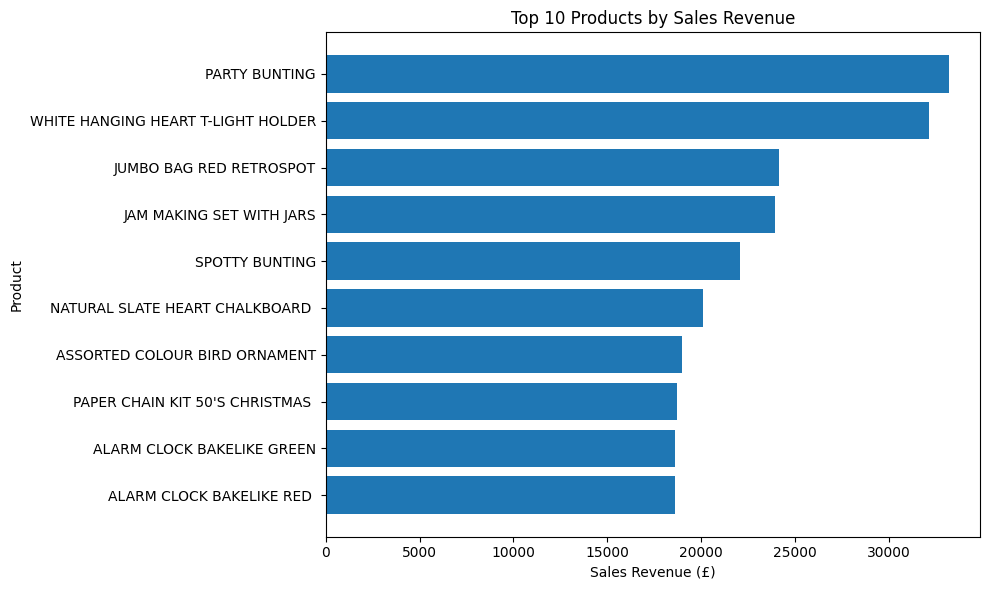

In [101]:
# Select top 10 products
top_products = product_sales.head(10)

# Plot the products
plt.figure(figsize=(10, 6))

plt.barh(
    top_products["Description"][::-1],
    top_products["Total_Sales"][::-1]
)

plt.title(
    "Top 10 Products by Sales Revenue"
)

plt.xlabel("Sales Revenue (£)")
plt.ylabel("Product")

plt.tight_layout()

plt.show()

***Interpretation:*** The retail store owner's sales efforts across intemational markets could be centred around these 10 products to capitalize on their high revenue potential.

In [102]:
# Calculate product sales within each country
country_product_sales = (
    df_clean
    .groupby(
        [
            "Country",
            "StockCode",
            "Description"
        ]
    )["Sales"]
    .sum()
    .reset_index()
)

country_product_sales.columns = [
    "Country",
    "StockCode",
    "Description",
    "Total_Sales"
]

country_product_sales.head()

,Country,StockCode,Description,Total_Sales
0,Australia,20665,RED RETROSPOT PURSE,17.7
1,Australia,20685,DOORMAT RED RETROSPOT,79.5
2,Australia,20712,JUMBO BAG WOODLAND ANIMALS,61.1
3,Australia,20713,JUMBO BAG OWLS,19.5
4,Australia,20717,STRAWBERRY SHOPPER BAG,12.5


***Interpretation:*** Through examining the product sales per country, the retail store's owners can better understand the demand distribution. Therefore, they can optimize inventory and shipping operations to ensure these products are readily available and delivered on time.

In [103]:
# Find the product with the highest sales in each country
highest_product_by_country = (
    country_product_sales
    .loc[
        country_product_sales
        .groupby("Country")["Total_Sales"]
        .idxmax()
    ]
    .reset_index(drop=True)
)

highest_product_by_country

,Country,StockCode,Description,Total_Sales
0,Australia,48138,DOORMAT UNION FLAG,266.70
1,Austria,15056P,EDWARDIAN PARASOL PINK,142.80
2,Bahrain,22649,STRAWBERRY FAIRY CAKE TEAPOT,39.60
3,Belgium,22326,ROUND SNACK BOXES SET OF4 WOODLAND,743.40
4,Brazil,22366,DOORMAT AIRMAIL,67.50
5,Canada,21558,SKULL LUNCH BOX WITH CUTLERY,45.90
6,Channel Islands,21621,VINTAGE UNION JACK BUNTING,187.00
7,Cyprus,82484,WOOD BLACK BOARD ANT WHITE FINISH,146.10
8,Czech Republic,21428,SET3 BOOK BOX GREEN GINGHAM FLOWER,51.00
9,Denmark,23256,CHILDRENS CUTLERY SPACEBOY,149.40


***Interpretation:*** The highest-selling product per country provides the retail store's owners with insight into which product contributes most to its revenue. Its owners may then employ additional advertising strategies (eg. social media/tv ads) to further drive sales of these products.

In [104]:
# Calculate quantity sold for each product within each country
country_product_quantity = (
    df_clean
    .groupby(
        [
            "Country",
            "StockCode",
            "Description"
        ]
    )["Quantity"]
    .sum()
    .reset_index()
)

country_product_quantity.columns = [
    "Country",
    "StockCode",
    "Description",
    "Total_Quantity"
]

In [105]:
# Find the product with the highest quantity sold in each country
highest_quantity_by_country = (
    country_product_quantity
    .loc[
        country_product_quantity
        .groupby("Country")["Total_Quantity"]
        .idxmax()
    ]
    .reset_index(drop=True)
)

highest_quantity_by_country

,Country,StockCode,Description,Total_Quantity
0,Australia,22087,PAPER BUNTING WHITE LACE,48
1,Austria,22326,ROUND SNACK BOXES SET OF4 WOODLAND,36
2,Bahrain,85040A,S/4 PINK FLOWER CANDLES IN BOWL,12
3,Belgium,22326,ROUND SNACK BOXES SET OF4 WOODLAND,252
4,Brazil,21166,COOK WITH WINE METAL SIGN,12
5,Canada,23190,BUNDLE OF 3 SCHOOL EXERCISE BOOKS,24
6,Channel Islands,20725,LUNCH BAG RED RETROSPOT,70
7,Cyprus,21974,SET OF 36 PAISLEY FLOWER DOILIES,24
8,Czech Republic,22930,BAKING MOULD HEART MILK CHOCOLATE,18
9,Denmark,22629,SPACEBOY LUNCH BOX,72


***Interpretation:*** The highest-selling product per country and product with highest quantity sold per country differ. Yet, the retail store's owners can still capitalize on maintaining adequate inventory levels as these products still contribute to revenue though to a smaller degree.

In [106]:
# Calculate the number of unique orders per month
monthly_orders = (
    df_clean
    .groupby("YearMonth")["InvoiceNo"]
    .nunique()
    .reset_index()
)

monthly_orders.columns = [
    "YearMonth",
    "Number_of_Orders"
]

monthly_orders.head()

,YearMonth,Number_of_Orders
0,2010-12,1365
1,2011-01,965
2,2011-02,972
3,2011-03,1296
4,2011-04,1087


***Interpretation:*** The number of orders per month aids the retail store's owners in differentiating between more customers or more orders versus larger orders from existing customers.

In [107]:
# Combine monthly sales and monthly orders
monthly_summary = pd.merge(
    monthly_sales,
    monthly_orders,
    on="YearMonth"
)

monthly_summary.head()

,YearMonth,Total_Sales,Number_of_Orders
0,2010-12,339693.44,1365
1,2011-01,266619.60,965
2,2011-02,231309.41,972
3,2011-03,295317.36,1296
4,2011-04,234846.65,1087


***Interpretation:*** The retail store's owners can get a better understanding of monthly sales performance via a side-by-side view of sales and
number of orders. From a glance at this data, it appears a few orders generate much revenue per month.

In [108]:
# Calculate Average Order Value
monthly_summary[
    "Average_Order_Value"
] = (
    monthly_summary["Total_Sales"] /
    monthly_summary["Number_of_Orders"]
)

monthly_summary.head()

,YearMonth,Total_Sales,Number_of_Orders,Average_Order_Value
0,2010-12,339693.44,1365,248.859663
1,2011-01,266619.60,965,276.289741
2,2011-02,231309.41,972,237.972644
3,2011-03,295317.36,1296,227.868333
4,2011-04,234846.65,1087,216.050276


***Interpretation:*** The data shows that based on the first few results each order generated on average 300 pounds sterling (rounded). In other words, this is the average spend per customer on an order. As the number of orders and average order value fluctuate, revenue is driven by both more orders and greater customer spend and not just one factor.

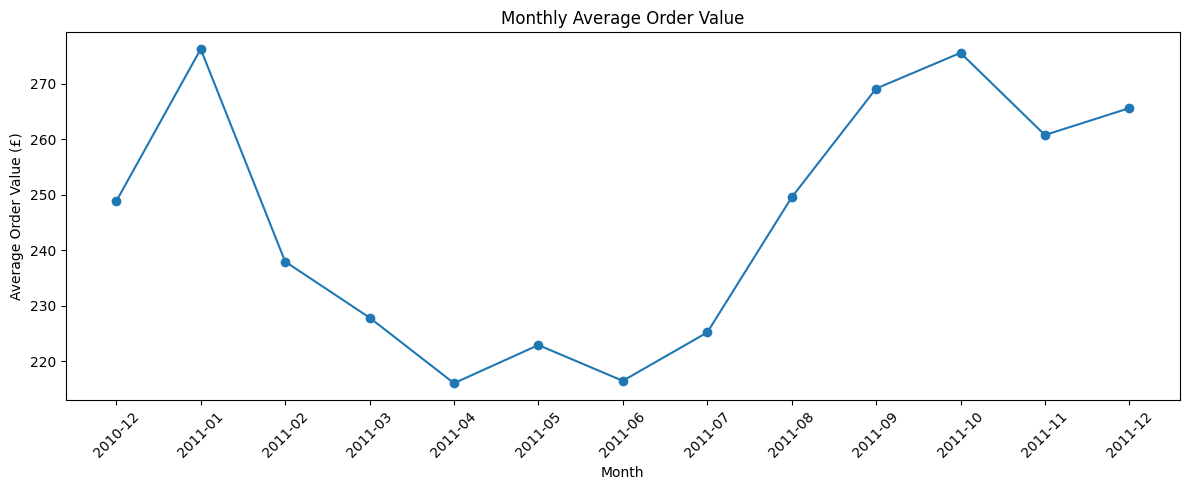

In [109]:
# Plot monthly Average Order Value
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_summary["YearMonth"],
    monthly_summary["Average_Order_Value"],
    marker="o"
)

plt.title(
    "Monthly Average Order Value"
)

plt.xlabel("Month")
plt.ylabel("Average Order Value (£)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

***Explanation:***  The data shows that customers spent varying amounts on orders over 2010-2011. The greatest spend were in Jan 2011 and Oct
2011 , with a drastic decrease from Feb 2011 to Jul 2011. The low points were prime opportunities for the store's owners to implement product
bundling, cross-selling/upselling, discounts and other promotions to improve sales.

In [110]:
# Remove transactions without a CustomerID
customer_data = df_clean[
    df_clean["CustomerID"].notna()
]

# Calculate customer-level measures
customer_value = (
    customer_data
    .groupby("CustomerID")
    .agg(
        Total_Sales=("Sales", "sum"),
        Number_of_Orders=("InvoiceNo", "nunique"),
        Total_Quantity=("Quantity", "sum")
    )
    .reset_index()
)

# Calculate average order value
customer_value[
    "Average_Order_Value"
] = (
    customer_value["Total_Sales"] /
    customer_value["Number_of_Orders"]
)

# Display the customer with the highest sales
most_valuable_customer = (
    customer_value
    .sort_values(
        "Total_Sales",
        ascending=False
    )
    .head(1)
)

most_valuable_customer

,CustomerID,Total_Sales,Number_of_Orders,Total_Quantity,Average_Order_Value
1806,14911.0,71856.09,191,26425,376.209895


***Interpretation:*** Customer 14911 was identified as the "most valuable customer" during the period and therefore could be extended special
offers like free shipping once per month or coupons to encourage their continued patronage to the retail store.

In [111]:
# Find the top 10 customers by total sales
top_10_customers = (
    customer_value
    .sort_values(
        "Total_Sales",
        ascending=False
    )
    .head(10)
)

top_10_customers

,CustomerID,Total_Sales,Number_of_Orders,Total_Quantity,Average_Order_Value
1806,14911.0,71856.09,191,26425,376.209895
1237,14096.0,35914.24,17,11093,2112.602353
3839,17841.0,28270.68,123,11667,229.842927
533,13089.0,25778.43,81,9199,318.252222
317,12748.0,16038.01,181,6497,88.607790
1278,14156.0,14941.55,37,4758,403.825676
1233,14088.0,14604.34,13,2844,1123.410769
2086,15311.0,13889.20,91,4889,152.628571
3726,17675.0,13274.21,31,4466,428.200323
1889,15039.0,12997.87,47,4927,276.550426


***Interpretation:*** These customers constitute the retail store's "high-revenue customer group". Likewise, they could be extended special offers to
maintain their loyalty.

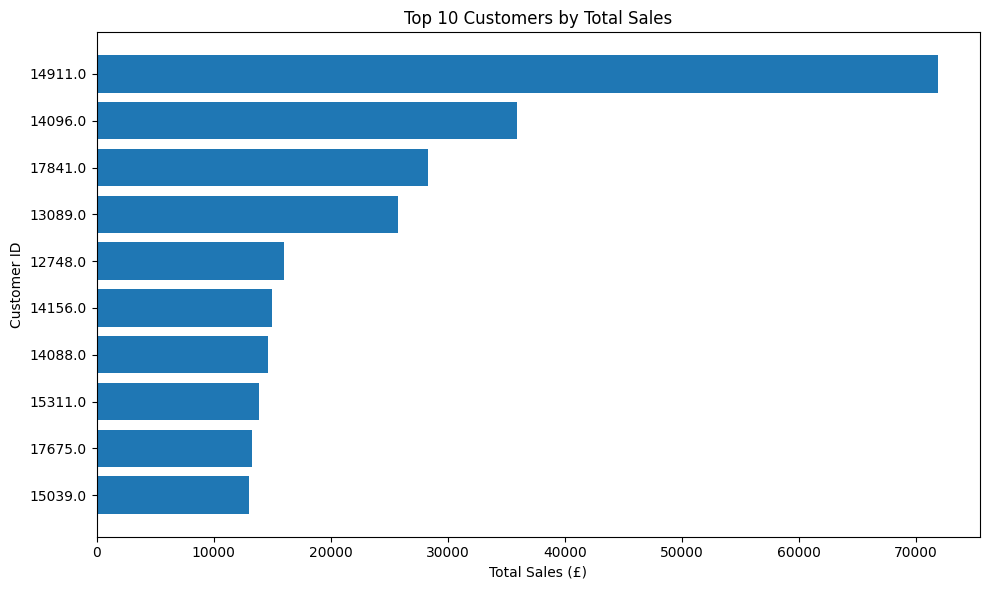

In [112]:
# Plot the top 10 customers
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_customers["CustomerID"].astype(str)[::-1],
    top_10_customers["Total_Sales"][::-1]
)

plt.title(
    "Top 10 Customers by Total Sales"
)

plt.xlabel("Total Sales (£)")
plt.ylabel("Customer ID")

plt.tight_layout()

plt.show()

***Interpretation:*** The high revenue experienced by the online retail store can be credited to Customer with 14911, as this customer's sales far
exceed the others in the high-revenue customer group. Data on this customer's purchasing frequency would further substantiate this finding.

In [113]:
# Calculate total revenue
total_revenue = df_clean["Sales"].sum()

# Calculate total unique orders
total_orders = (
    df_clean["InvoiceNo"]
    .nunique()
)

# Calculate total products sold
total_products_sold = (
    df_clean["Quantity"]
    .sum()
)

# Calculate average order value
average_order_value = (
    total_revenue /
    total_orders
)

# Display the results
print(
    "Total Revenue: £",
    round(total_revenue, 2)
)

print(
    "Total Orders:",
    total_orders
)

print(
    "Total Products Sold:",
    total_products_sold
)

print(
    "Average Order Value: £",
    round(average_order_value, 2)
)

Total Revenue: £ 4341420.38
Total Orders: 17590
Total Products Sold: 1580945
Average Order Value: £ 246.81


***Interpretation:***  Over the course of 2010-2011, the online retail store earned 4,341,420.38 pounds sterling in total revenue from 17590 orders of 1,580,945 products valued at 246.81 pounds sterling on average per order.